# KAGGLE playground series: Predicting Student Test Scores

In [5]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('data/train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [19]:
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


#### Linear algebra: Every cell in df is called vector, all non-null vector

In [20]:
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [4]:
df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [12]:
numerical_cols = df.select_dtypes(include='number').columns
numerical_cols

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score'], dtype='object')

In [13]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
categorical_cols

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

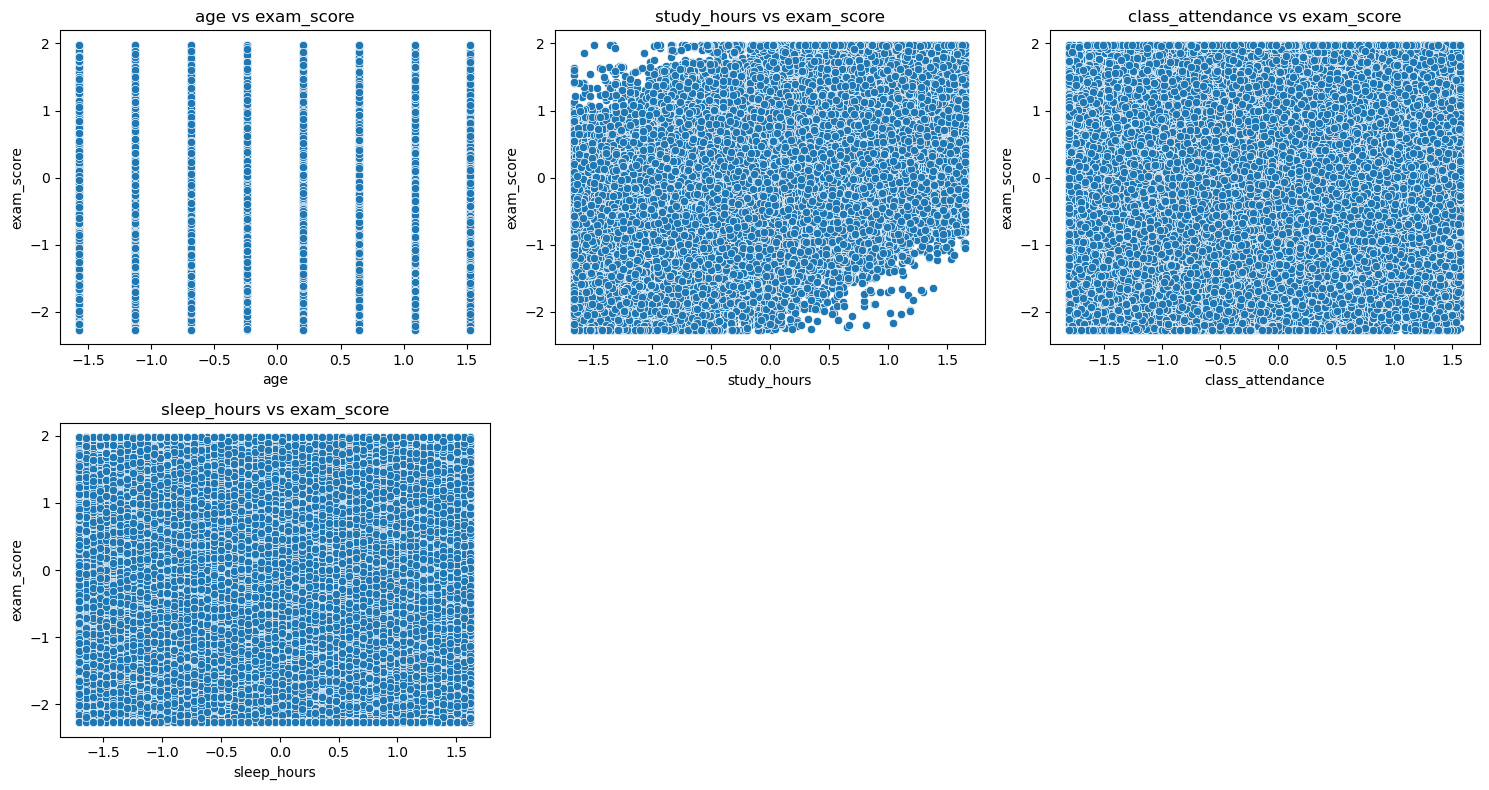

In [41]:
from sklearn.preprocessing import StandardScaler

# Scale a copy of df
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

# Prepare splot
label = 'exam_score'
feature_cols = numerical_cols.drop(label)
n_cols = 3
n_plots = len(feature_cols)
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = axes.flatten()


for ax, col in zip(axes, feature_cols):
    sns.scatterplot(
        data=df_scaled,
        x=col,
        y=label,
        ax=ax
    )
    ax.set_title(f"{col} vs {label}")
    ax.set_xlabel(col)
    ax.set_ylabel(label)

# Remove unused subplots
for ax in axes[len(feature_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

#### Issues: Vertical Spikes, overploted
#### Discover: Heteroscedastic relationship (use log1p or other common options: log() or sqrt()

<Axes: xlabel='age', ylabel='exam_score'>

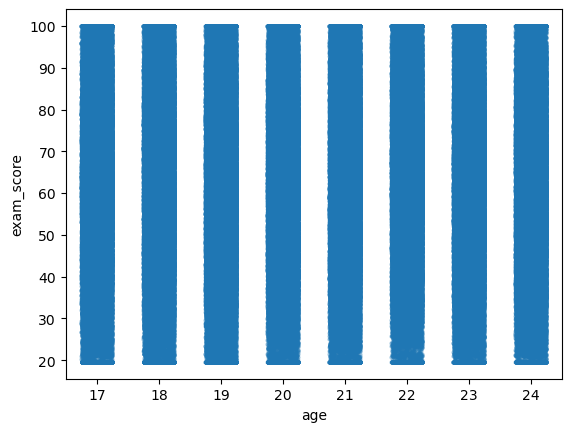

In [23]:
sns.stripplot(
    data=df,
    x='age',
    y=label,
    jitter=0.25,
    size=3,
    alpha=0.4
)


<Axes: xlabel='age', ylabel='exam_score'>

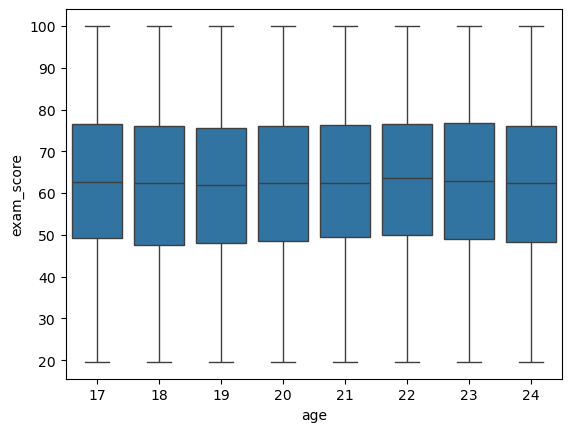

In [24]:
sns.boxplot(
    data=df,
    x='age',
    y=label,
)


<Axes: xlabel='age', ylabel='exam_score'>

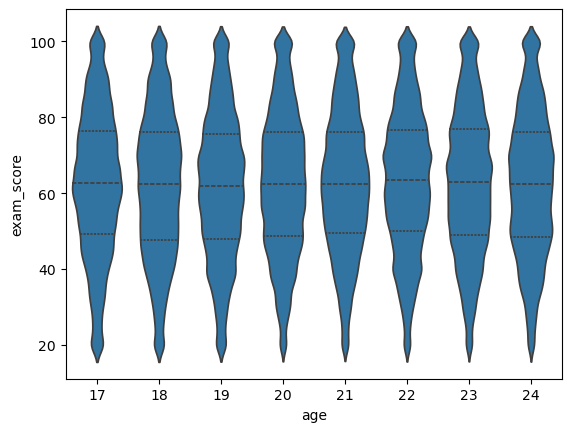

In [25]:
sns.violinplot(
    data=df,
    x='age',
    y=label,
    inner="quartile",
)

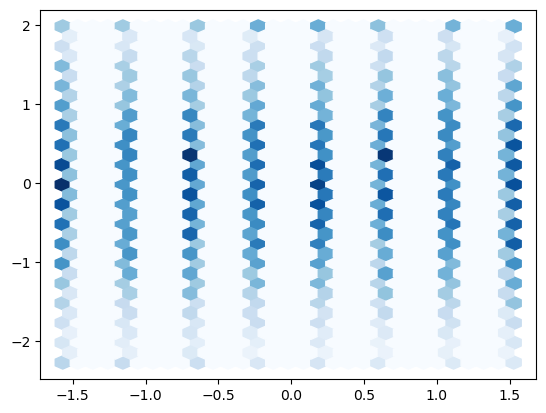

In [28]:
col = 'age'
plt.hexbin(
    df_scaled[col],
    df_scaled[label],
    gridsize=30,
    cmap="Blues"
)


<Axes: xlabel='age', ylabel='exam_score'>

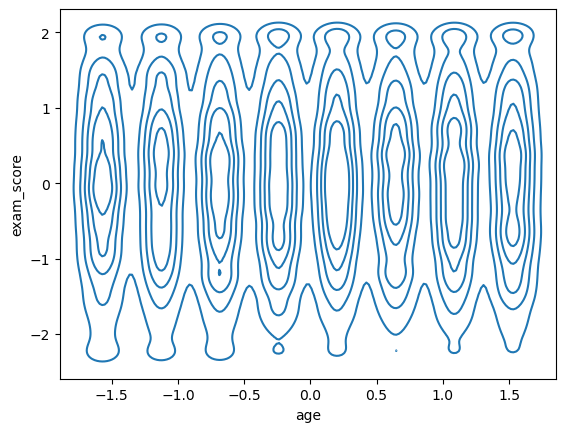

In [29]:
sns.kdeplot(
    data=df_scaled,
    x=col,
    y=label,
    levels=6
)


In [ ]:
cols = df.select_dtypes(include='number')

n_cols = 3
n_plots = len(cols)
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.histplot(data=df, x=col, bins=50, ax=ax)

# Remove unused subplots
for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


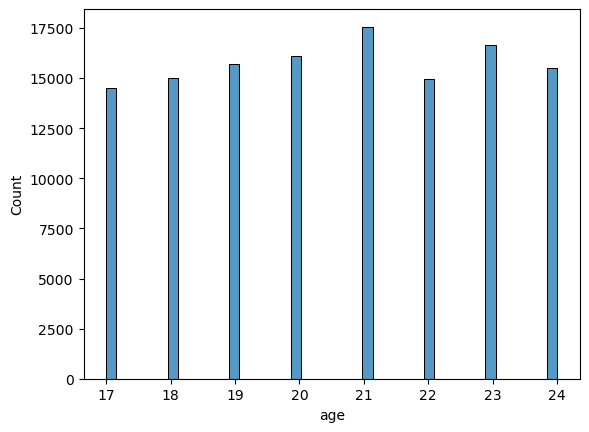

In [48]:
sns.histplot(data=df.sample(frac=0.2, random_state=42), x='age')
plt.show()

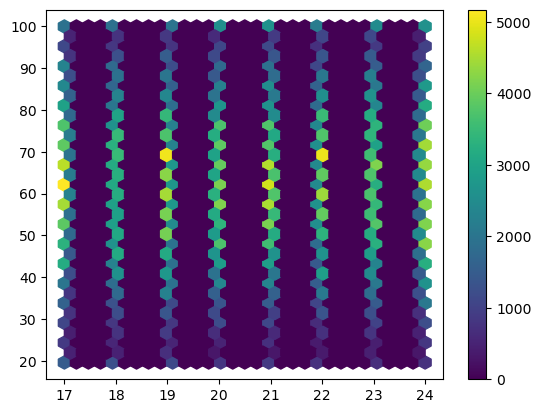

In [50]:
plt.hexbin(df['age'], df[label], gridsize=30)
plt.colorbar()

In [52]:
df.columns

Index(['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

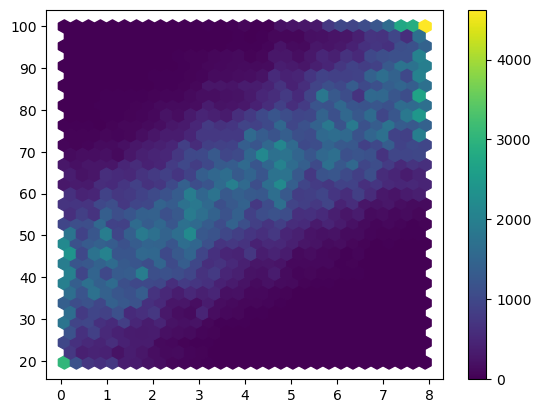

In [54]:
plt.hexbin(df['study_hours'], df[label], gridsize=30)
plt.colorbar()

<Axes: xlabel='study_hours', ylabel='exam_score'>

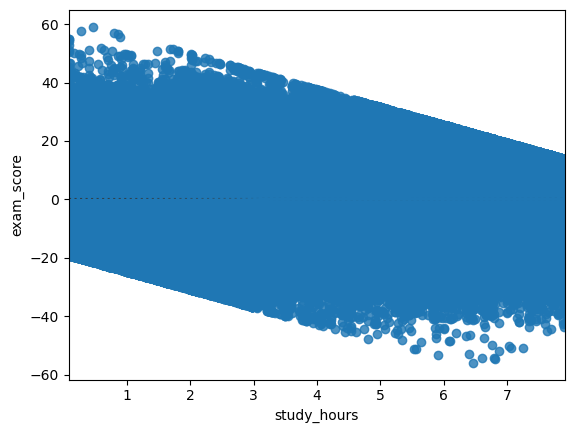

In [55]:
sns.residplot(x=df['study_hours'], y=df[label], lowess=True)